# MEEP Mode Solver — TFLN Ridge Waveguide

Fundamental TE mode of thin-film lithium niobate ridge waveguide at lambda=1.55 µm.
Reference: Ying Li et al., ACS Omega 2023, 8(10), 9644–9651.

**Design:** SiO2 cladding / LiNbO3 slab 220 nm / LiNbO3 ridge 180 nm (total 400 nm),
ridge width 1.1 µm, sidewall angle 17°.

**Expected:** n_eff ~ 1.85, n_group ~ 2.20.
``background_material="sio2"`` fills unpatterned space with SiO2.

### Imports

In [1]:
import gdsfactory as gf
import matplotlib.pyplot as plt
import numpy as np

import gsim.meep as gm
from gsim.common.stack.extractor import Layer, LayerStack

plt.close()

gf.gpdk.PDK.activate()

### LiNbO3 material (Zelmon 1997)

LiNbO3 is birefringent and is now registered as a uniaxial material
in ``gsim.common.stack.materials.MATERIALS_DB`` (notebook no longer
manually registers it).  Both ordinary and extraordinary Sellmeier
models from Zelmon et al. (JOSA B 14(12), 3319--3322, 1997) are included:

Ordinary:
  n_o^2 = 1 + 2.6734 lam^2/(lam^2 - 0.01764) + 1.2290 lam^2/(lam^2 - 0.05914)
            + 12.614 lam^2/(lam^2 - 474.60)

Extraordinary:
  n_e^2 = 1 + 2.9804 lam^2/(lam^2 - 0.02047) + 0.5981 lam^2/(lam^2 - 0.0666)
            + 8.9543 lam^2/(lam^2 - 416.08)

For x-cut TFLN the TE mode's dominant E-field aligns with the
extraordinary axis (zz).

### Build the GDS component

In [2]:
SLAB_WIDTH = 5.0  # um --- wide slab
CORE_WIDTH = 1.1  # um --- w0 from reference design
LENGTH = 10.0  # um --- waveguide length (arbitrary for mode solving)

c = gf.Component()

# LiNbO3 ridge (layer 2) --- narrow core on top
c.add_polygon(
    [
        (-LENGTH / 2, -CORE_WIDTH / 2),
        (LENGTH / 2, -CORE_WIDTH / 2),
        (LENGTH / 2, CORE_WIDTH / 2),
        (-LENGTH / 2, CORE_WIDTH / 2),
    ],
    layer=(2, 0),
)

# Ports at both ends
c.add_port(
    name="o1",
    center=(-LENGTH / 2, 0),
    width=CORE_WIDTH,
    orientation=180,
    layer=(1, 0),
)
c.add_port(
    name="o2",
    center=(LENGTH / 2, 0),
    width=CORE_WIDTH,
    orientation=0,
    layer=(1, 0),
)

print(f"Component: {c.name}")
print(f"  Ports:  {[p.name for p in c.ports]}")
print(f"  Layers: {list(c.layers)}")

Component: Unnamed_0
  Ports:  ['o1', 'o2']
  Layers: [(2, 0)]


### Layer stack

SiO2 fills background via ``background_material="sio2"``.

In [3]:
SLAB_THICKNESS = 0.22  # um  (h3)
CORE_THICKNESS = 0.40  # um --- total LiNbO3 thickness
RIDGE_THICKNESS = CORE_THICKNESS - SLAB_THICKNESS  # 0.18 um

layers = {
    "box": Layer(
        name="box",
        gds_layer=(0, 0),
        zmin=-1.0,
        zmax=0.0,
        thickness=1.0,
        material="sio2",
        layer_type="dielectric",
    ),
    "slab": Layer(
        name="slab",
        gds_layer=(1, 0),
        zmin=0.0,
        zmax=SLAB_THICKNESS,
        thickness=SLAB_THICKNESS,
        material="linbo3",
        layer_type="dielectric",
    ),
    "ridge": Layer(
        name="ridge",
        gds_layer=(2, 0),
        zmin=SLAB_THICKNESS,
        zmax=CORE_THICKNESS,
        thickness=RIDGE_THICKNESS,
        material="linbo3",
        layer_type="dielectric",
        sidewall_angle=17.0,
    ),
}
stack = LayerStack(layers=layers)

print("Layer stack (+ SiO2 background):")
for name, l in stack.layers.items():
    print(
        f"  {name:6s}  z=[{l.zmin:+.3f}, {l.zmax:+.3f}]  "
        f"t={l.thickness:.3f}  material={l.material}  gds={l.gds_layer}"
    )

Layer stack (+ SiO2 background):
  box     z=[-1.000, +0.000]  t=1.000  material=sio2  gds=(0, 0)
  slab    z=[+0.000, +0.220]  t=0.220  material=linbo3  gds=(1, 0)
  ridge   z=[+0.220, +0.400]  t=0.180  material=linbo3  gds=(2, 0)


### Solve

In [4]:
WAVELENGTH = 1.55  # um
RESOLUTION = 64  # grid points per um
PML_THICKNESS = WAVELENGTH  # um

sim = gm.Simulation(
    geometry=gm.Geometry(component=c, stack=stack),
    domain=gm.Domain(
        pml=PML_THICKNESS,
        margin_z=(0.0, 0.5),
    ),
)
sim.mode_solver.wavelengths = [WAVELENGTH]
sim.mode_solver.fundamental().at_port("o1")
sim.mode_solver.y_span = SLAB_WIDTH
sim.mode_solver.n_field_y = 1000
sim.mode_solver.n_field_z = 1000
sim.mode_solver.background_material = "sio2"

sweep = sim.solve_modes()
mode = sweep.at(WAVELENGTH).band(1)

print(f"n_eff     = {mode.n_eff}")
print(f"n_group   = {mode.n_group}")
print(f"kdom      = {[f'{k:.6f}' for k in mode.kdom]}")
print(f"band      = {mode.band_num}, parity = {mode.parity}")
print(f"fields    = {list(mode.fields.keys())}")
for comp, arr in mode.fields.items():
    print(f"  {comp}: shape={arr.shape}  |max|={np.abs(arr).max():.6f}")

  meep-7fb3006b  completed  2m 22s


Extracting results.tar.gz...


Downloaded 10 files to /Users/vahid/doplaydo/gsim/sim-data-meep-7fb3006b
n_eff     = 1.8600558281393749
n_group   = 2.259414906519319
kdom      = ['1.200036', '-0.000000', '0.000000']
band      = 1, parity = NO_PARITY
fields    = ['Ex', 'Ey', 'Ez', 'Hx', 'Hy', 'Hz']
  Ex: shape=(1000, 1000)  |max|=0.597531
  Ey: shape=(1000, 1000)  |max|=2.475644
  Ez: shape=(1000, 1000)  |max|=0.372790
  Hx: shape=(1000, 1000)  |max|=1.995995
  Hy: shape=(1000, 1000)  |max|=0.413430
  Hz: shape=(1000, 1000)  |max|=4.933792


### Index profile

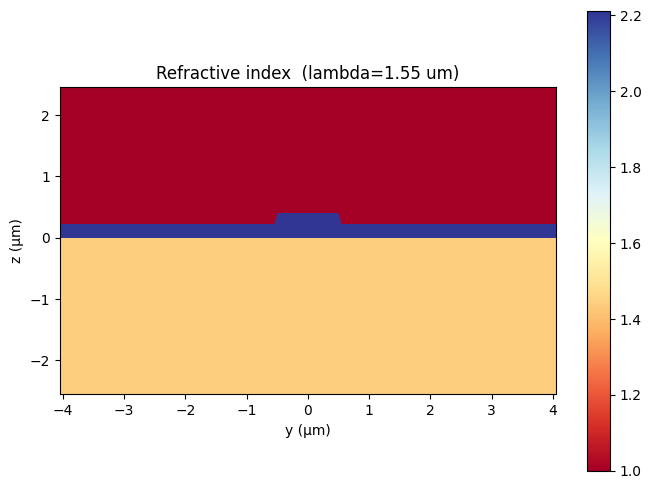

(<Figure size 700x500 with 2 Axes>,
 <Axes: title={'center': 'Refractive index  (lambda=1.55 um)'}, xlabel='y (µm)', ylabel='z (µm)'>)

In [5]:
mode.plot_index(show=True)

### Mode profile (interactive)

``|field|`` maps for every component with zoom / pan / hover. The view is
auto-cropped to the mode region and axes use equal aspect.

In [6]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

comps = [c for c in ("Ex", "Ey", "Ez", "Hx", "Hy", "Hz") if c in mode.fields]

# Crop to the (small, centered) mode region and downsample so the embedded
# heatmaps stay light-weight for the docs while remaining smooth on zoom.
energy = sum(np.abs(mode.fields[c]) ** 2 for c in comps)
thr = 0.02 * energy.max()
yi = np.where(energy.max(axis=0) > thr)[0]
zi = np.where(energy.max(axis=1) > thr)[0]
dy, dz = mode.y_grid[1] - mode.y_grid[0], mode.z_grid[1] - mode.z_grid[0]
pad = 0.4  # µm margin around the mode
y0, y1 = (
    max(yi.min() - int(pad / dy), 0),
    min(yi.max() + int(pad / dy) + 1, mode.y_grid.size),
)
z0, z1 = (
    max(zi.min() - int(pad / dz), 0),
    min(zi.max() + int(pad / dz) + 1, mode.z_grid.size),
)
max_pts = 140  # per axis
sy, sz = max(1, (y1 - y0) // max_pts), max(1, (z1 - z0) // max_pts)
y_sub, z_sub = mode.y_grid[y0:y1:sy], mode.z_grid[z0:z1:sz]

fig = make_subplots(
    rows=2,
    cols=3,
    subplot_titles=[f"|{c}|" for c in comps],
    horizontal_spacing=0.08,
    vertical_spacing=0.12,
)

for i, comp in enumerate(comps):
    row, col = i // 3 + 1, i % 3 + 1
    # Mode fields are in arbitrary units; normalize each panel to its own max
    # and quantize to 8-bit (0..255). Plotly embeds arrays as binary, so this
    # keeps the notebook small while staying visually identical.
    panel = np.abs(mode.fields[comp][z0:z1:sz, y0:y1:sy])
    panel = np.round(panel / panel.max() * 255).astype(np.uint8)
    fig.add_trace(
        go.Heatmap(
            x=y_sub,
            y=z_sub,
            z=panel,
            colorscale="Inferno",
            showscale=False,
            zmin=0,
            zmax=255,
            hovertemplate=(
                "y=%{x:.3f} µm<br>z=%{y:.3f} µm<br>"
                "|" + comp + "| (rel.)=%{z}<extra></extra>"
            ),
        ),
        row=row,
        col=col,
    )
    x_anchor = "x" if i == 0 else f"x{i + 1}"
    fig.update_xaxes(title_text="y (µm)", row=row, col=col)
    fig.update_yaxes(
        title_text="z (µm)", scaleanchor=x_anchor, scaleratio=1, row=row, col=col
    )

fig.update_layout(
    height=750,
    width=1050,
    title_text=(
        f"TFLN ridge waveguide fundamental TE mode  "
        f"(lambda={WAVELENGTH:.2f} µm, w0={CORE_WIDTH:.1f} µm, n_eff={mode.n_eff:.4f})"
    ),
)
fig.show()